# Extending diffsed

The framework is modular: PSD model, mean SFH, dust law, SSP
templates, and inference method can each be swapped independently.
This tutorial shows how.

**By the end you will know how to:**
1. Implement a custom PSD model (e.g., broken power law, Matérn)
2. Swap the dust attenuation law
3. Load alternative SSP templates
4. Add new free parameters
5. Use the multiscale gradient scalogram for survey design

In [1]:
import os
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

from diffsed.models.sfh.psd_models import psd_drw, drw_acf
from diffsed.models.sfh.gp_sfh import compute_sqrt_power_drw, gp_from_xi
from diffsed.utils.grid import make_log_age_grid, grid_spacing, log_age_to_age_yr

import sys; sys.path.insert(0, ".")
import sys; sys.path.insert(0, "..")
from _plot_style import setup_style, COLORS
setup_style()

FIG_DIR = "../notebook_figures"
os.makedirs(FIG_DIR, exist_ok=True)
def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"T06_{name}.png"),
                bbox_inches="tight", dpi=72)

N_GRID = 128
log_ages = make_log_age_grid(N_GRID)
d_log = grid_spacing(log_ages)
ages_yr = log_age_to_age_yr(log_ages)
ages_gyr = ages_yr / 1e9

## 1. Architecture Overview

```
┌─────────────────────────────────────────────────────────────┐
│  PSD Model       │  Mean SFH      │  SPS          │  Dust  │
│  (psd_models.py) │  (mean_sfh.py) │  (DSPS/JAX)   │  (CF00)│
│  ─────────────── │  ──────────────│  ────────────  │  ──────│
│  • DRW           │  • Dbl power   │  • FSPS/MIST  │  • CF00│
│  • Matérn        │    law         │  • BC03       │  • KC13│
│  • Broken PL     │  • Delayed-τ   │  • BPASS      │  • C00 │
│  • Custom        │  • Custom      │  • ProGeny    │        │
└──────────┬───────┴───────┬────────┴──────┬────────┴──┬─────┘
           │               │               │           │
           ▼               ▼               ▼           ▼
      ┌────────────────────────────────────────────────────┐
      │  Differentiable Forward Model (JAX)                │
      │  H(ξ|d) = ½χ² + ½ξᵀξ                              │
      └───────────────────────┬────────────────────────────┘
                              │
           ┌──────────────────┼──────────────────┐
           ▼                  ▼                  ▼
        MAP/Adam         Ray Tracing          geoVI/MGVI
```

Each component is a pure JAX function.  Swapping a component means
providing a new function with the same signature.

## 2. Custom PSD Models

The DRW is the default, but any PSD can be plugged in.  The interface
requires a function `psd(omega, *params) -> P(omega)` that maps
angular frequencies to power.

### Example: Broken power law

$$P(\omega) = \frac{A}{1 + (\omega/\omega_b)^{\alpha_1 + \alpha_2}}$$

This allows different slopes above and below the break.

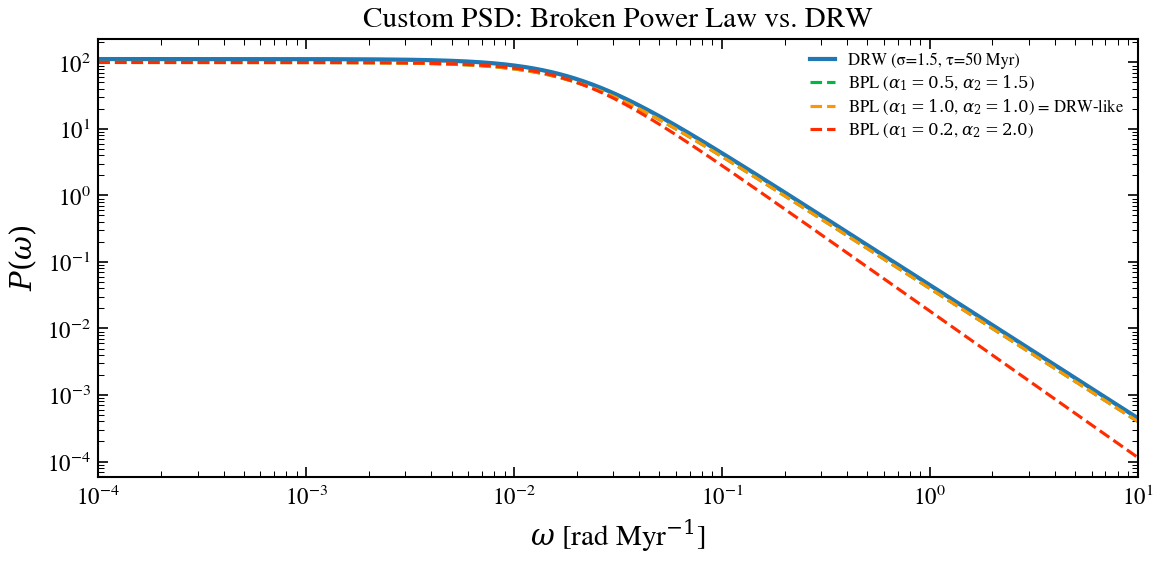

In [2]:
def psd_broken_powerlaw(omega, A, omega_break, alpha_lo, alpha_hi):
    """Broken power-law PSD with two spectral slopes."""
    x = omega / omega_break
    return A / (1.0 + x ** (alpha_lo + alpha_hi))

omega = jnp.logspace(-4, 1, 500)

fig, ax = plt.subplots(figsize=(8, 4))

# DRW reference
P_drw = psd_drw(omega, 1.5, 50.0)
ax.loglog(omega, P_drw, lw=2, color=COLORS["rt"], label="DRW (σ=1.5, τ=50 Myr)")

# Broken power law examples
for alpha_lo, alpha_hi, col, lab in [
    (0.5, 1.5, "C1", r"BPL ($\alpha_1=0.5$, $\alpha_2=1.5$)"),
    (1.0, 1.0, "C2", r"BPL ($\alpha_1=1.0$, $\alpha_2=1.0$) = DRW-like"),
    (0.2, 2.0, "C3", r"BPL ($\alpha_1=0.2$, $\alpha_2=2.0$)"),
]:
    P = psd_broken_powerlaw(omega, 100.0, 0.02, alpha_lo, alpha_hi)
    ax.loglog(omega, P, lw=1.5, color=col, ls="--", label=lab)

ax.set_xlabel(r"$\omega$ [rad Myr$^{-1}$]")
ax.set_ylabel(r"$P(\omega)$")
ax.set_title("Custom PSD: Broken Power Law vs. DRW")
ax.legend(fontsize=8); ax.set_xlim(1e-4, 10)
fig.tight_layout(); savefig(fig, "custom_psd"); plt.show()

### Registering a custom PSD

To use a custom PSD in the inference pipeline, implement
`compute_sqrt_power_custom()` following the same signature as
`compute_sqrt_power_drw()`:

```python
def compute_sqrt_power_custom(n_grid, d_log_age, *psd_params):
    """Return sqrt(P(k)) array of length n_grid//2 + 1."""
    freqs = jnp.fft.rfftfreq(n_grid, d=d_log_age)
    omega = 2 * jnp.pi * freqs
    P = my_psd_function(omega, *psd_params)
    return jnp.sqrt(P / d_log_age)
```

Then pass it to the model via the `psd_fn` argument.

## 3. Alternative Dust Laws

The Charlot & Fall (2000) two-component model is the default.  To use
Calzetti (2000) or Kriek & Conroy (2013), implement a function with
signature:

```python
def my_dust(wavelengths, ages, **dust_params):
    """Return transmission array of shape (n_ages, n_wave)."""
    ...
```

The function must be a pure JAX function (no numpy, no side effects)
for automatic differentiation to work.

## 4. Alternative SSP Templates

diffsed accepts any SSP template set in DSPS-compatible HDF5 format.
Pre-formatted templates from multiple SPS codes are available at:

`https://halos.as.arizona.edu/suchethacooray/ssp-spectra/`

To load a different library:

```python
ssp_bpass = load_ssp_data("path/to/bpass_chabrier.h5")
model = Model(spec, ssp_bpass, filters=filters)
```

The inference machinery, PSD model, and dust law are unchanged —
only the SSP spectra differ.  This allows systematic comparison of
SPL-induced uncertainties (Bellstedt & Robotham 2025).

## 5. Multiscale Gradient Scalogram

Because the forward model is differentiable, we can compute the
Jacobian $\partial f_\nu / \partial \theta_k$ at every wavelength.
The **multiscale gradient scalogram** (Eq. 25 of the paper) measures
sensitivity at each wavelength **and** spectral resolution:

$$C_k(\lambda_0, s) = \frac{1}{s} \int_{\lambda_0 - s/2}^{\lambda_0 + s/2} \left|\frac{\partial f_\nu}{\partial \theta_k}\right|^2 d\lambda$$

This reveals which parameters need spectroscopy (concentrated at fine
scales near absorption features) vs. photometry (sensitivity at all
scales).

In [3]:
# Placeholder for full scalogram computation
# (requires high-resolution SSP templates — C3K)
# See analysis notebook A05_gradient_sensitivity.py for the full
# implementation.

print("Scalogram computation requires C3K SSP templates (higher resolution).")
print("See A05_gradient_sensitivity.py for the full implementation.")

Scalogram computation requires C3K SSP templates (higher resolution).
See A05_gradient_sensitivity.py for the full implementation.


## Summary

| Extension | What to change | Inference machinery |
|-----------|---------------|---------------------|
| PSD model | `compute_sqrt_power_*()` | Unchanged |
| Mean SFH | `mean_sfh.py` | Unchanged |
| Dust law | `dust/*.py` | Unchanged |
| SSP templates | HDF5 file path | Unchanged |
| New parameters | `ParamSpec` + bijection | Unchanged |

The standardised loss function $H = \frac{1}{2}\chi^2 + \frac{1}{2}\xi^\top\xi$
and all five inference methods work for **any** combination of these
components, provided each is implemented as a differentiable JAX
function.